# <center>Lab 06 - 112078502 楊婷婷</center>
## SPEC
#### Goal
Predict the presence or absence of cardiac arrhythmia in a patient
#### Read this note carefully
- Submit to **eeclass** with your code file, the filename format should be ```Lab06_{student_id}.ipynb```. The notebook should contain
    1. Loading of dataset
    2. Splitting of dataset to training and testing data (test_size = 20% of the whole dataset)
    3. Building of a self-designed Logistic Regression model (Complete the TODO parts provided below)
    4. Plotting the loss curve.
    5. Plotting of the confusion matrix. (**Label 0 as positive**)
    6. Computing the F1-score of this confusion matrix. The F1-score should be at least 0.75
- Deadline: **2025-10-01(Wed) 23:59**
- Please make sure that we can rerun your code

#### Dataset
The [Arrhythmia](https://archive.ics.uci.edu/ml/datasets/Arrhythmia) dataset from UCI repository contains 280 variables collected from 452 patients. Its information helps in distinguishing between the presence and absence of cardiac arrhythmia and in classifying arrhytmia in one of the 16 groups. In this homework, we will just focus on building a Logistic Regression model that  can classify between the presence and absence of arrhythmia.<br><br>

Original class 1 refers to 'normal' ECG which we will regard as 'absence of arrhythmia' and the rest of the classes will be 'presence of arrhythmia'.

In [13]:
# load
# inline plotting instead of popping out
%matplotlib inline

import os
from IPython.display import Image
from IPython.display import display

import numpy as np
import pandas as pd

# scikit-learn 1.2.2
from numpy import interp #new version of scipy 1.16 remove th interp, use numpy.interp instead
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import auc, confusion_matrix, precision_score, recall_score, roc_curve
from sklearn.metrics import accuracy_score, classification_report, f1_score # add for lab6
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# cycler 0.10.0
# from cycler import cycler

# matplotlib  3.7.1
import matplotlib
matplotlib.rcParams.update({'font.size': 22})
plt = matplotlib.pyplot

# Make output directory
if not os.path.exists("output/") : os.mkdir("output/")

# Requirement 1 & 2
    1. Loading of dataset
    2. Splitting of dataset to training and testing data (test_size = 20% of the whole dataset)

In [14]:
'''1. Loading of dataset'''
data = pd.read_csv('http://archive.ics.uci.edu/ml/machine-learning-databases/'
                   'arrhythmia/arrhythmia.data', header=None, sep=',', engine='python')


print('--- print the raw data ----')
print('%d rows and %d columns' % (data.shape[0],data.shape[1]))
np.unique(data[len(data.columns)-1])
display(data.head(3))

# pre-process the data
data['arrhythmia'] = data[len(data.columns)-1].map(lambda x: 0 if x==1 else 1) # change class [1] -> 0, [2-16] ->1
data = data.drop(len(data.columns)-2, axis=1)

# check data balance or not
print('--- check data balance ----')
print(data.groupby(['arrhythmia']).size())

# pre-process -> removing col, rows contains '?'
data = data._get_numeric_data()
print('--- print the pre-processed data ----')
print('%d rows and %d columns' % (data.shape[0],data.shape[1]))
display(data.head(3))

print('--- check value of y, shape of x ----')
X = data.iloc[:, :-1]  # The first to second-last columns are the features
y = data.iloc[:, -1]   # The last column is the ground-truth label
print(np.unique(y))
print(X.shape)


'''2. Splitting of dataset to training and testing data (test_size = 20% of the whole dataset)'''
print('--- split to training/ test data ----')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=20181004)
print(X_train.shape, X_test.shape)

# Standardizing the training and test datasets
# Note that we are scaling based on the information from the training data
# Then we apply the scaling that is done from training data to the test data
sc = StandardScaler()
sc.fit(X_train)
X_train_std = sc.transform(X_train)
X_test_std = sc.transform(X_test)

--- print the raw data ----
452 rows and 280 columns


,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,279
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,8
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,6
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,10


--- check data balance ----
arrhythmia
0    245
1    207
dtype: int64
--- print the pre-processed data ----
452 rows and 275 columns


,0,1,2,3,4,5,6,7,8,9,...,270,271,272,273,274,275,276,277,278,arrhythmia
0,75,0,190,80,91,193,371,174,121,-16,...,0.0,9.0,-0.9,0.0,0.0,0.9,2.9,23.3,49.4,1
1,56,1,165,64,81,174,401,149,39,25,...,0.0,8.5,0.0,0.0,0.0,0.2,2.1,20.4,38.8,1
2,54,0,172,95,138,163,386,185,102,96,...,0.0,9.5,-2.4,0.0,0.0,0.3,3.4,12.3,49.0,1


--- check value of y, shape of x ----
[0 1]
(452, 274)
--- split to training/ test data ----
(361, 274) (91, 274)


# Requirement 3
Building of a self-designed Logistic Regression model (Complete the TODO parts provided below)

In [15]:
class LogisticRegression(object):

    def __init__(self, eta=0.0005, n_epoch=1000, random_state=1): # change eta from 0.5 to 0.0005, as we see loss flunctuate when eta = 0.5
        """Feel free to change the hyperparameters"""
        self.eta = eta
        self.n_epoch = n_epoch
        self.random_state = random_state

    def fit(self, X, y):
        rgen = np.random.RandomState(self.random_state)
        self.w_ = rgen.normal(loc=0.0, scale=0.01, size=1 + X.shape[1])
        self.cost_ = []

        for i in range(self.n_epoch):
            net_input = self.net_input(X) # whole training dataset
            output = self.activation(net_input)
            gradient_weights, gradient_bias = self.gradient(X, output, y)
            self.w_[1:] += self.eta * gradient_weights
            self.w_[0] += self.eta * gradient_bias
            cost = self.loss(output, y)
            self.cost_.append(cost)
        return self

    def net_input(self, X):
        """Calculate net input"""
        return np.dot(X, self.w_[1:]) + self.w_[0]

    def loss(self, output, y):
        """Calculate cross entropy loss"""
        # TODO
        # The log-likelihood for a Bernoulli distribution leads directly to the cross-entropy form. -Ex~P[log Q(x)]
        epsilon = 1e-9 # avoid log (0)
        return -np.sum(y * np.log(output + epsilon) + (1 - y) * np.log(1 - output + epsilon))

    def gradient(self, X, output, y):
        """Calculate the partial derivative of cross entropy loss with respect to weights"""
        errors = (y - output)
        return errors.dot(X), errors.sum()
        # errors.dot(X) = sum of [y-y_hat]x
        # errors.sum() : handles bias sum of [y- y_hat]

    def activation(self, z):
        """Compute logistic sigmoid activation"""
        # TODO
        return 1.0 / (1.0 + np.exp(-z))

    def predict(self, X):
        """Return class label after unit step"""
        # TODO
        net_input = self.net_input(X)
        prob = self.activation(net_input)
        return np.where(prob >= 0.5, 1, 0)

# Requirement 4
4. Plotting the loss curve.

Test Accuracy: 0.7912087912087912
              precision    recall  f1-score   support

           0       0.79      0.77      0.78        43
           1       0.80      0.81      0.80        48

    accuracy                           0.79        91
   macro avg       0.79      0.79      0.79        91
weighted avg       0.79      0.79      0.79        91



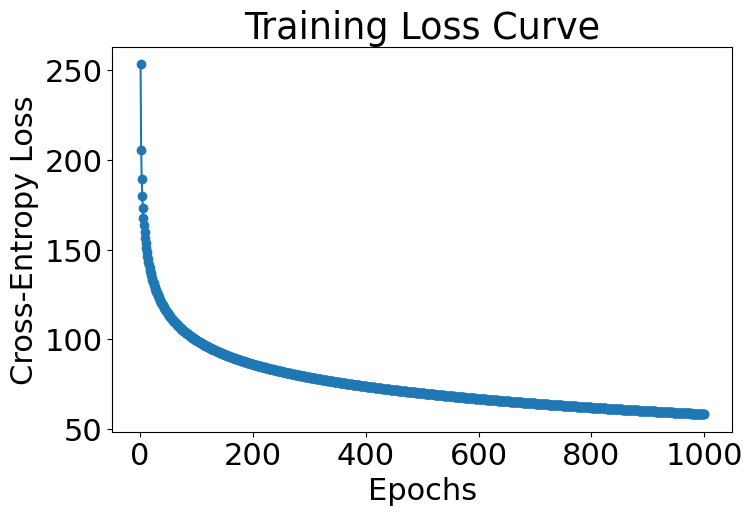

In [16]:
model = LogisticRegression()
model.fit(X_train_std, y_train.values)

y_pred = model.predict(X_test_std)

print("Test Accuracy:", accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

# plot the curve
plt.figure(figsize=(8,5))
plt.plot(range(1, len(model.cost_) + 1), model.cost_, marker='o')
plt.xlabel("Epochs")
plt.ylabel("Cross-Entropy Loss")
plt.title("Training Loss Curve")
plt.show()

# Requirement 5
 5. Plotting of the confusion matrix. (**Label 0 as positive**)

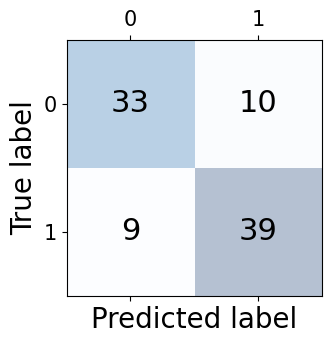

In [11]:
lr = LogisticRegression()
lr.fit(X_train_std, y_train)
y_pred = lr.predict(X_test_std)
confmat = confusion_matrix(y_true=y_test, y_pred=y_pred)

fig, ax = plt.subplots(figsize=(4,4))
ax.matshow(confmat, cmap=plt.cm.Blues, alpha=0.3)
for i in range(confmat.shape[0]):
    for j in range(confmat.shape[1]):
        ax.text(x=j, y=i, s=confmat[i, j], va='center', ha='center')

plt.xlabel('Predicted label')
plt.ylabel('True label')

plt.tight_layout()
plt.savefig('./output/lab06_hw.png', dpi=300)
for item in ([ax.title, ax.xaxis.label, ax.yaxis.label] +
             ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(20)
for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)
plt.show()

# Requirement 6
6. Computing the F1-score of this confusion matrix. The F1-score should be at least 0.75

In [12]:
f1 = f1_score(y_test, y_pred)
print("F1 Score:", f1)

F1 Score: 0.8041237113402062
